In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, coherent, destroy, expect, mesolve, qeye, sigmaz, tensor

In [2]:
N = 20
wr = 2.0 * 2 * np.pi
wq = 3.0 * 2 * np.pi
chi = 0.025 * 2 * np.pi
delta = abs(wr - wq)
g = np.sqrt(delta * chi)

print(f"delta / 2pi = {delta / (2 * np.pi):.3f}")
print(f"g / 2pi     = {g / (2 * np.pi):.3f}")
print(f"delta / g  = {delta / g:.3f}")

a = tensor(destroy(N), qeye(2))
Id = tensor(qeye(N), qeye(2))
sz = tensor(qeye(N), sigmaz())
nc = a.dag() * a
H = (wr * (a.dag() * a + Id / 2.0) + (wq / 2.0) * sz + chi * (a.dag() * a + Id / 2.0) * sz)
psi0 = tensor(coherent(N, np.sqrt(4)), (basis(2, 0) + basis(2, 1)).unit())
tlist = np.linspace(0, 250, 1000)
res = mesolve(H, psi0, tlist, c_ops=[], e_ops=[], options={"nsteps": 5000})

n_cavity = expect(nc, res.states)
qubit_z = expect(sz, res.states)

delta / 2pi = 1.000
g / 2pi     = 0.158
delta / g  = 6.325


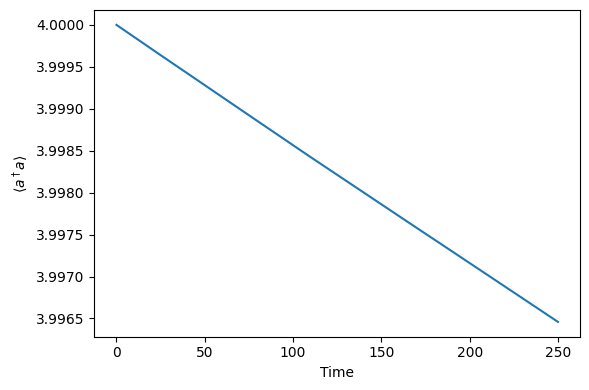

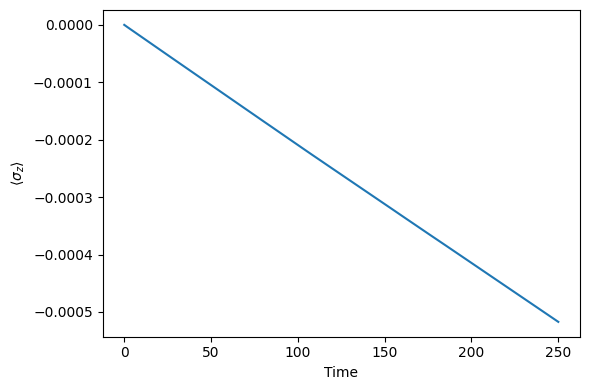

In [3]:
# Plotting
plt.figure(figsize=(6, 4))
plt.plot(tlist, n_cavity)
plt.xlabel("Time")
plt.ylabel(r"$\langle a^\dagger a \rangle$")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(tlist, qubit_z)
plt.xlabel("Time")
plt.ylabel(r"$\langle \sigma_z \rangle$")
plt.tight_layout()
plt.show()